# Setup

In [1]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import math
import numpy as np
from tqdm import tqdm
import tensorflow as tf
from tensorflow import keras
from scipy.linalg import sqrtm
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input

I0000 00:00:1775079711.315285 2232402 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# Hyperparameters

In [ ]:
# Common hyperparameters and settings
batch_size = 32
img_size = 32
original_img_size = 28
img_channels = 1
clip_min = -1.0
clip_max = 1.0
num_epochs = 10
learning_rate = 2e-4
beta_1=0.5
beta_2=0.9

# WGAN-specific settings
noise_dim = 128
gp_weight = 10.0
discriminator_extra_steps = 3

# Diffusion model-specific settings
total_timesteps = 1000
norm_groups = 8  # Number of groups used in GroupNormalization layer
first_conv_channels = 64
channel_multiplier = [1, 2, 4, 8]
widths = [first_conv_channels * mult for mult in channel_multiplier]
has_attention = [False, False, True, True]
num_res_blocks = 2  # Number of residual blocks in each stage of the UNet

results_dir = "result"
samples_dir = os.path.join(results_dir, "samples")
os.makedirs(results_dir, exist_ok=True)
os.makedirs(samples_dir, exist_ok=True)

# Dataset

In [ ]:
# Load the Fashion-MNIST dataset
(train_images_raw, train_labels), (test_images, test_labels) = keras.datasets.fashion_mnist.load_data()
print(f"Number of examples: {len(train_images_raw)}")
print(f"Shape of the images in the dataset: {train_images_raw.shape[1:]}")


# Prepare datasets for WGAN model
train_images = train_images_raw.reshape(-1, original_img_size, original_img_size, img_channels).astype("float32")
train_images = (train_images - 127.5) / 127.5
print(f"WGAN images shape: {train_images.shape}")

wgan_train_ds = (
    tf.data.Dataset.from_tensor_slices(train_images)
    .shuffle(1024)
    .batch(batch_size, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)


# Prepare datasets for diffusion model
def augment(img):
    """Flips an image left/right randomly."""
    return tf.image.random_flip_left_right(img)

def resize_and_rescale(img, size):
    """Resize the image to the desired size first and then
    rescale the pixel values in the range [-1.0, 1.0]."""
    img = tf.cast(img, dtype=tf.float32)
    img = tf.image.resize(img, size=size, antialias=True)
    img = img / 127.5 - 1.0
    img = tf.clip_by_value(img, clip_min, clip_max)
    return img

def train_preprocessing(img):
    img = tf.expand_dims(img, axis=-1)
    img = resize_and_rescale(img, size=(img_size, img_size))
    img = augment(img)
    return img

train_ds = (
    tf.data.Dataset.from_tensor_slices(train_images_raw)
    .map(train_preprocessing, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(batch_size, drop_remainder=True)
    .shuffle(batch_size * 2)
    .prefetch(tf.data.AUTOTUNE)
)

Number of examples: 60000
Shape of the images in the dataset: (28, 28)
WGAN images shape: (60000, 28, 28, 1)


I0000 00:00:1775079717.626991 2232402 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6335 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2080 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5


# Models

## WGAN-GP

### Create the discriminator (the critic in the original WGAN)

In [4]:
def conv_block(
    x,
    filters,
    activation,
    kernel_size=(3, 3),
    strides=(1, 1),
    padding="same",
    use_bias=True,
    use_bn=False,
    use_dropout=False,
    drop_value=0.5,
):
    x = layers.Conv2D(
        filters, kernel_size, strides=strides, padding=padding, use_bias=use_bias
    )(x)
    if use_bn:
        x = layers.BatchNormalization()(x)
    x = activation(x)
    if use_dropout:
        x = layers.Dropout(drop_value)(x)
    return x


def get_discriminator_model():
    img_input = layers.Input(shape=(original_img_size, original_img_size, img_channels))
    # Zero pad the input to make the input images size to (32, 32, 1).
    x = layers.ZeroPadding2D((2, 2))(img_input)
    x = conv_block(
        x,
        64,
        kernel_size=(5, 5),
        strides=(2, 2),
        use_bn=False,
        use_bias=True,
        activation=layers.LeakyReLU(0.2),
        use_dropout=False,
        drop_value=0.3,
    )
    x = conv_block(
        x,
        128,
        kernel_size=(5, 5),
        strides=(2, 2),
        use_bn=False,
        activation=layers.LeakyReLU(0.2),
        use_bias=True,
        use_dropout=True,
        drop_value=0.3,
    )
    x = conv_block(
        x,
        256,
        kernel_size=(5, 5),
        strides=(2, 2),
        use_bn=False,
        activation=layers.LeakyReLU(0.2),
        use_bias=True,
        use_dropout=True,
        drop_value=0.3,
    )
    x = conv_block(
        x,
        512,
        kernel_size=(5, 5),
        strides=(2, 2),
        use_bn=False,
        activation=layers.LeakyReLU(0.2),
        use_bias=True,
        use_dropout=False,
        drop_value=0.3,
    )

    x = layers.Flatten()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(1)(x)

    d_model = keras.models.Model(img_input, x, name="discriminator")
    return d_model


d_model = get_discriminator_model()
d_model.summary()

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d (ZeroPadding2D)  │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 16, 16, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 256)      │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 2, 2, 512)      │     3,277,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,305,409 (16.42 MB)

 Trainable params: 4,305,409 (16.42 MB)

 Non-trainable params: 0 (0.00 B)

### Create the Generator

In [5]:
def upsample_block(
    x,
    filters,
    activation,
    kernel_size=(3, 3),
    strides=(1, 1),
    up_size=(2, 2),
    padding="same",
    use_bn=False,
    use_bias=True,
    use_dropout=False,
    drop_value=0.3,
):
    x = layers.UpSampling2D(up_size)(x)
    x = layers.Conv2D(
        filters, kernel_size, strides=strides, padding=padding, use_bias=use_bias
    )(x)

    if use_bn:
        x = layers.BatchNormalization()(x)

    if activation:
        x = activation(x)
    if use_dropout:
        x = layers.Dropout(drop_value)(x)
    return x


def get_generator_model():
    noise = layers.Input(shape=(noise_dim,))
    x = layers.Dense(4 * 4 * 256, use_bias=False)(noise)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Reshape((4, 4, 256))(x)
    x = upsample_block(
        x,
        128,
        layers.LeakyReLU(0.2),
        strides=(1, 1),
        use_bias=False,
        use_bn=True,
        padding="same",
        use_dropout=False,
    )
    x = upsample_block(
        x,
        64,
        layers.LeakyReLU(0.2),
        strides=(1, 1),
        use_bias=False,
        use_bn=True,
        padding="same",
        use_dropout=False,
    )
    x = upsample_block(
        x, 1, layers.Activation("tanh"), strides=(1, 1), use_bias=False, use_bn=True
    )
    # At this point, we have an output which has the same shape as the input, (32, 32, 1).
    # We will use a Cropping2D layer to make it (28, 28, 1).
    x = layers.Cropping2D((2, 2))(x)

    g_model = keras.models.Model(noise, x, name="generator")
    return g_model


g_model = get_generator_model()
g_model.summary()

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │       524,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 4096)           │        16,384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 1)      │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 1)      │             4 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cropping2d (Cropping2D)         │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 910,660 (3.47 MB)

 Trainable params: 902,082 (3.44 MB)

 Non-trainable params: 8,578 (33.51 KB)

### Create the WGAN-GP model

In [ ]:
class WGAN(keras.Model):
    def __init__(
        self,
        discriminator,
        generator,
        latent_dim,
        discriminator_extra_steps=3,
        gp_weight=gp_weight,
    ):
        super().__init__()
        self.discriminator = discriminator
        self.generator = generator
        self.latent_dim = latent_dim
        self.d_steps = discriminator_extra_steps
        self.gp_weight = gp_weight

    def compile(self, d_optimizer, g_optimizer, d_loss_fn, g_loss_fn):
        super().compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.d_loss_fn = d_loss_fn
        self.g_loss_fn = g_loss_fn

    def gradient_penalty(self, batch_size, real_images, fake_images):
        """Calculates the gradient penalty.

        This loss is calculated on an interpolated image
        and added to the discriminator loss.
        """
        # Get the interpolated image
        alpha = tf.random.uniform([batch_size, 1, 1, 1], 0.0, 1.0)
        diff = fake_images - real_images
        interpolated = real_images + alpha * diff

        with tf.GradientTape() as gp_tape:
            gp_tape.watch(interpolated)
            # 1. Get the discriminator output for this interpolated image.
            pred = self.discriminator(interpolated, training=True)

        # 2. Calculate the gradients w.r.t to this interpolated image.
        grads = gp_tape.gradient(pred, [interpolated])[0]
        # 3. Calculate the norm of the gradients.
        norm = tf.sqrt(tf.reduce_sum(tf.square(grads), axis=[1, 2, 3]))
        gp = tf.reduce_mean((norm - 1.0) ** 2)
        return gp

    def train_step(self, real_images):
        if isinstance(real_images, tuple):
            real_images = real_images[0]

        # Get the batch size
        batch_size = tf.shape(real_images)[0]

        # For each batch, we are going to perform the
        # following steps as laid out in the original paper:
        # 1. Train the generator and get the generator loss
        # 2. Train the discriminator and get the discriminator loss
        # 3. Calculate the gradient penalty
        # 4. Multiply this gradient penalty with a constant weight factor
        # 5. Add the gradient penalty to the discriminator loss
        # 6. Return the generator and discriminator losses as a loss dictionary

        # Train the discriminator first. The original paper recommends training
        # the discriminator for `x` more steps (typically 5) as compared to
        # one step of the generator. Here we will train it for 3 extra steps
        # as compared to 5 to reduce the training time.
        for i in range(self.d_steps):
            # Get the latent vector
            random_latent_vectors = tf.random.normal(
                shape=(batch_size, self.latent_dim)
            )
            with tf.GradientTape() as tape:
                # Generate fake images from the latent vector
                fake_images = self.generator(random_latent_vectors, training=True)
                # Get the logits for the fake images
                fake_logits = self.discriminator(fake_images, training=True)
                # Get the logits for the real images
                real_logits = self.discriminator(real_images, training=True)

                # Calculate the discriminator loss using the fake and real image logits
                d_cost = self.d_loss_fn(real_img=real_logits, fake_img=fake_logits)
                # Calculate the gradient penalty
                gp = self.gradient_penalty(batch_size, real_images, fake_images)
                # Add the gradient penalty to the original discriminator loss
                d_loss = d_cost + gp * self.gp_weight

            # Get the gradients w.r.t the discriminator loss
            d_gradient = tape.gradient(d_loss, self.discriminator.trainable_variables)
            # Update the weights of the discriminator using the discriminator optimizer
            self.d_optimizer.apply_gradients(
                zip(d_gradient, self.discriminator.trainable_variables)
            )

        # Train the generator
        # Get the latent vector
        random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))
        with tf.GradientTape() as tape:
            # Generate fake images using the generator
            generated_images = self.generator(random_latent_vectors, training=True)
            # Get the discriminator logits for fake images
            gen_img_logits = self.discriminator(generated_images, training=True)
            # Calculate the generator loss
            g_loss = self.g_loss_fn(gen_img_logits)

        # Get the gradients w.r.t the generator loss
        gen_gradient = tape.gradient(g_loss, self.generator.trainable_variables)
        # Update the weights of the generator using the generator optimizer
        self.g_optimizer.apply_gradients(
            zip(gen_gradient, self.generator.trainable_variables)
        )
        return {"d_loss": d_loss, "g_loss": g_loss}

### Create a Keras callback that periodically saves generated images

In [7]:
class GANMonitor(keras.callbacks.Callback):
    def __init__(self, num_img=16, latent_dim=128, samples_dir=samples_dir):
        self.num_img = num_img
        self.latent_dim = latent_dim
        self.save_dir = samples_dir
        os.makedirs(self.save_dir, exist_ok=True)

    def on_epoch_end(self, epoch, logs=None):
        random_latent_vectors = tf.random.normal(shape=(self.num_img, self.latent_dim))
        generated_images = self.model.generator(random_latent_vectors)
        generated_images = (generated_images * 127.5) + 127.5
        generated_images = tf.clip_by_value(generated_images, 0.0, 255.0).numpy().astype(np.uint8)

        num_rows, num_cols = 2, self.num_img // 2
        fig, axes = plt.subplots(num_rows, num_cols, figsize=(14, 4))
        for i, image in enumerate(generated_images):
            image = image.squeeze(-1) if img_channels == 1 else image
            axes[i // num_cols, i % num_cols].imshow(image, cmap="gray" if img_channels == 1 else None)
            axes[i // num_cols, i % num_cols].axis("off")

        fig.suptitle(f"WGAN-GP: Generated Images after Epoch {epoch + 1}", fontsize=14)
        plt.tight_layout()
        fig.savefig(os.path.join(self.save_dir, f"wgan_epoch_{epoch + 1:03d}.png"), dpi=150, bbox_inches="tight")
        plt.show()

### Train the end-to-end model

Epoch 1/10


I0000 00:00:1775079725.886761 2232789 service.cc:153] XLA service 0x79e2ec03bf60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775079725.886777 2232789 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 2080 SUPER, Compute Capability 7.5 (Driver: 12.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1775079726.158345 2232789 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
W0000 00:00:1775079726.652395 2232789 random_ops.cc:62] Warning: Using tf.random.uniform with XLA compilation will ignore seeds; consider using tf.random.stateless_uniform instead if reproducible behavior is desired. random_uniform/RandomUniform
I0000 00:00:1775079727.265991 2232789 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1775079728.101598 2232789 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_15219__.206


   3/1875 ━━━━━━━━━━━━━━━━━━━━ 1:27 47ms/step - d_loss: 1.6001 - g_loss: -3.3550   

I0000 00:00:1775079746.845465 2232789 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - d_loss: -5.4404 - g_loss: -14.2951

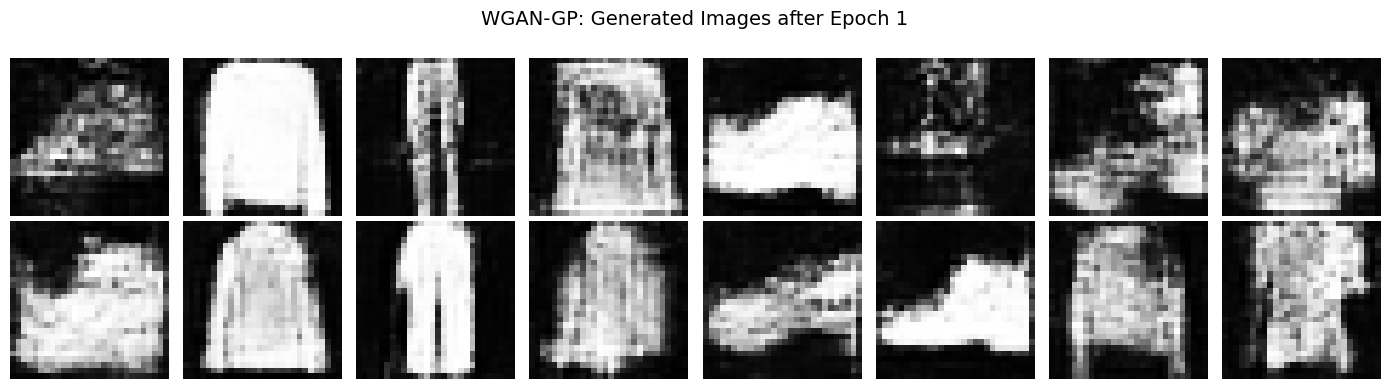

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 102s 40ms/step - d_loss: -2.1891 - g_loss: -5.4245
Epoch 2/10
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - d_loss: -3.2571 - g_loss: -4.8543

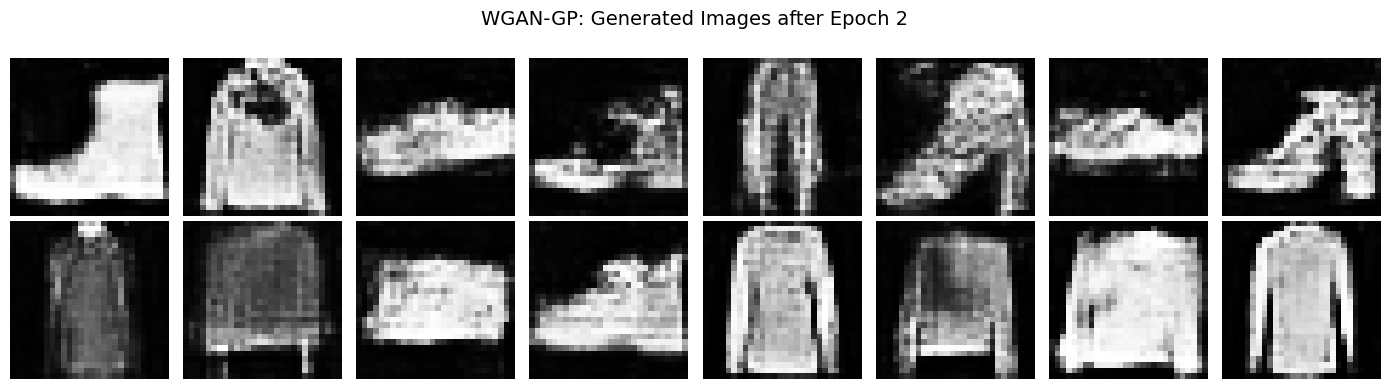

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 72s 39ms/step - d_loss: -3.0054 - g_loss: -0.6613
Epoch 3/10
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - d_loss: -2.6105 - g_loss: -2.1605

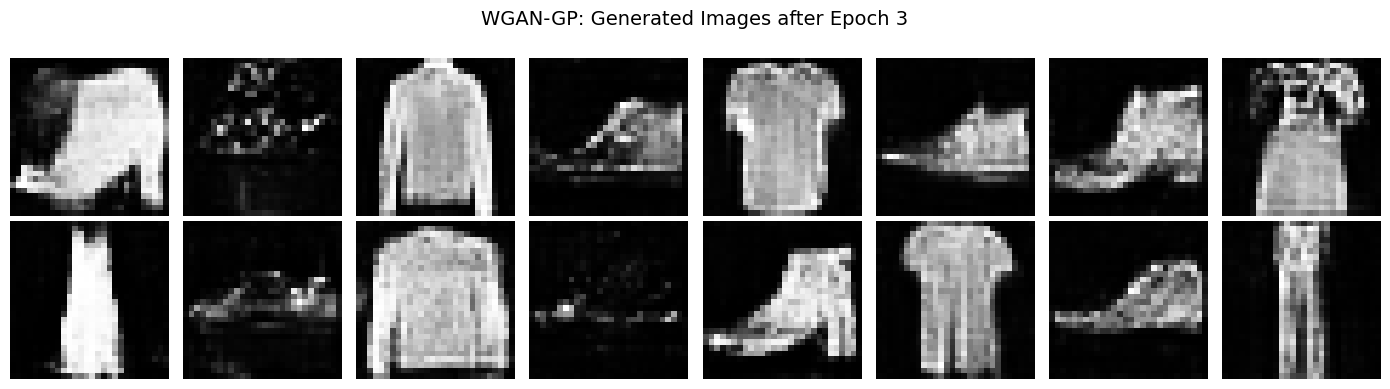

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 73s 39ms/step - d_loss: -1.9621 - g_loss: -1.6614
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - d_loss: -2.2157 - g_loss: -1.5531

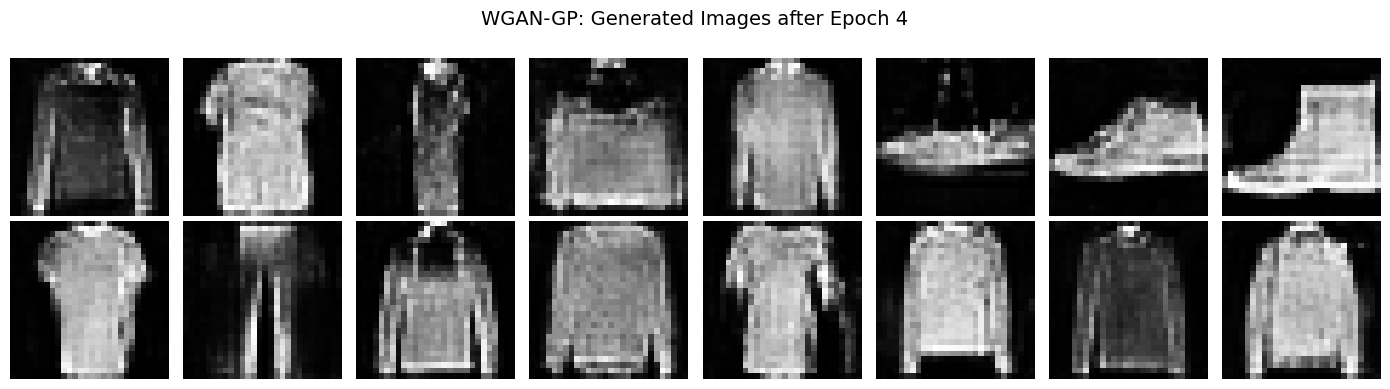

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 72s 39ms/step - d_loss: -2.6360 - g_loss: -6.0686
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - d_loss: -2.0850 - g_loss: -2.5749

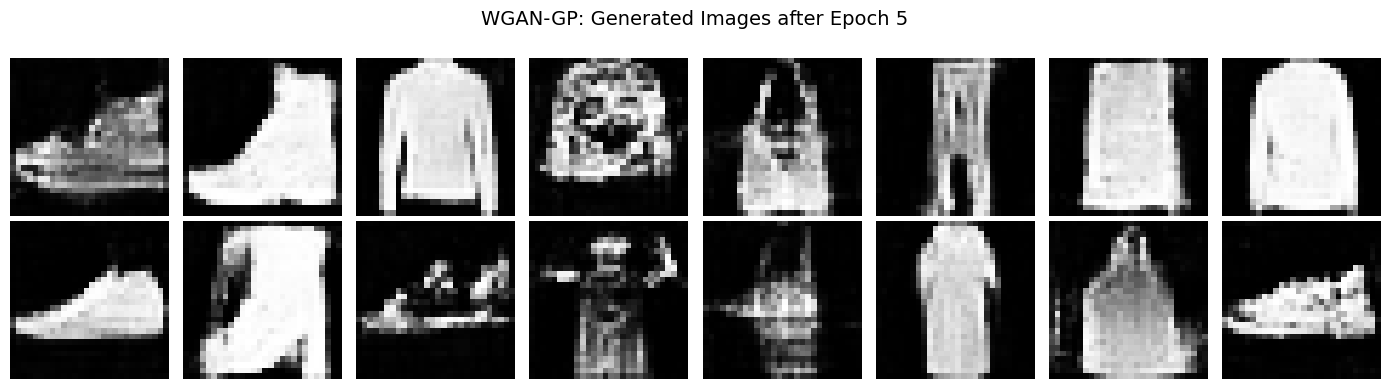

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 72s 39ms/step - d_loss: -1.4187 - g_loss: 2.7232
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - d_loss: -1.9521 - g_loss: -1.2569

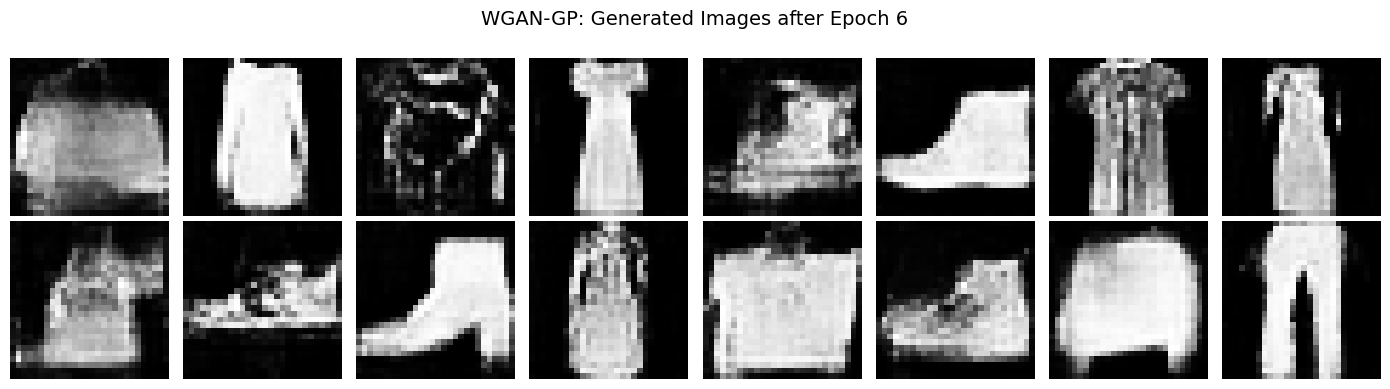

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 72s 39ms/step - d_loss: 0.6005 - g_loss: 3.8239 
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - d_loss: -1.7591 - g_loss: -1.8530

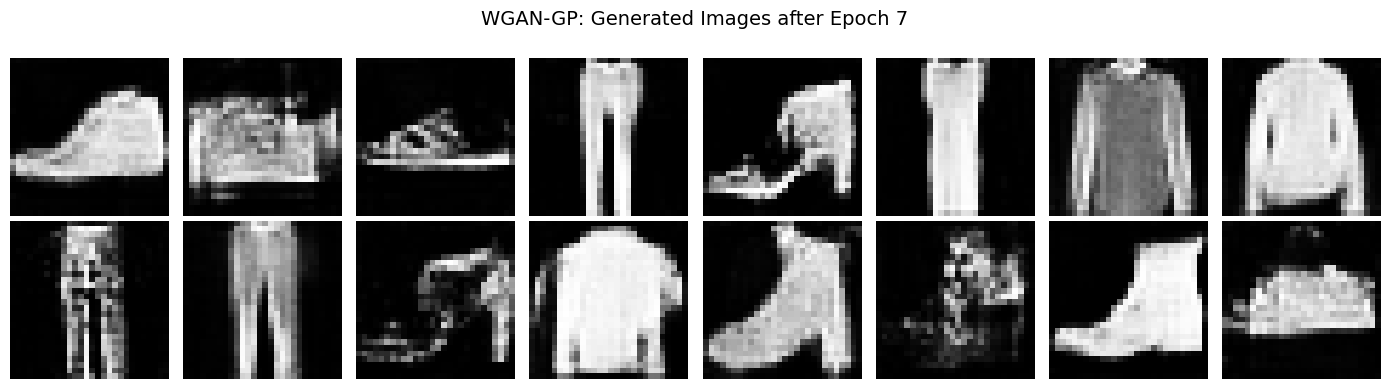

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 72s 38ms/step - d_loss: -2.8783 - g_loss: -5.4112
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - d_loss: -1.6444 - g_loss: -2.7085

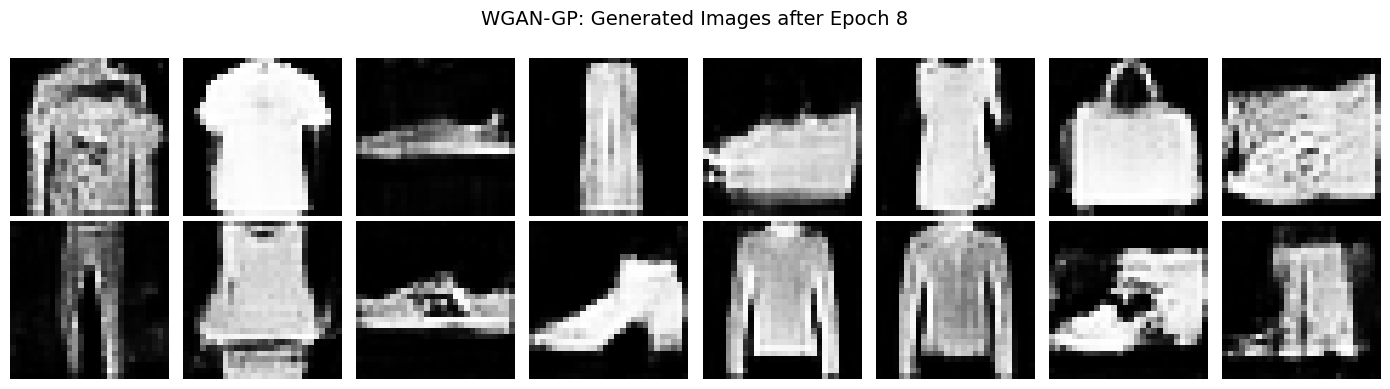

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 72s 39ms/step - d_loss: -1.7519 - g_loss: 6.1393
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - d_loss: -1.5621 - g_loss: -1.9766

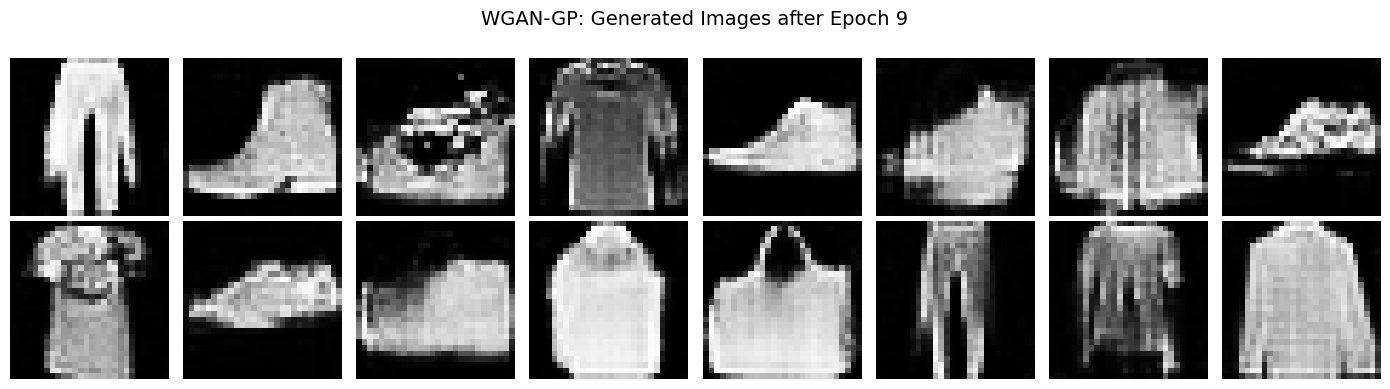

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 72s 39ms/step - d_loss: -2.0641 - g_loss: -3.4717
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - d_loss: -1.5474 - g_loss: -3.0285

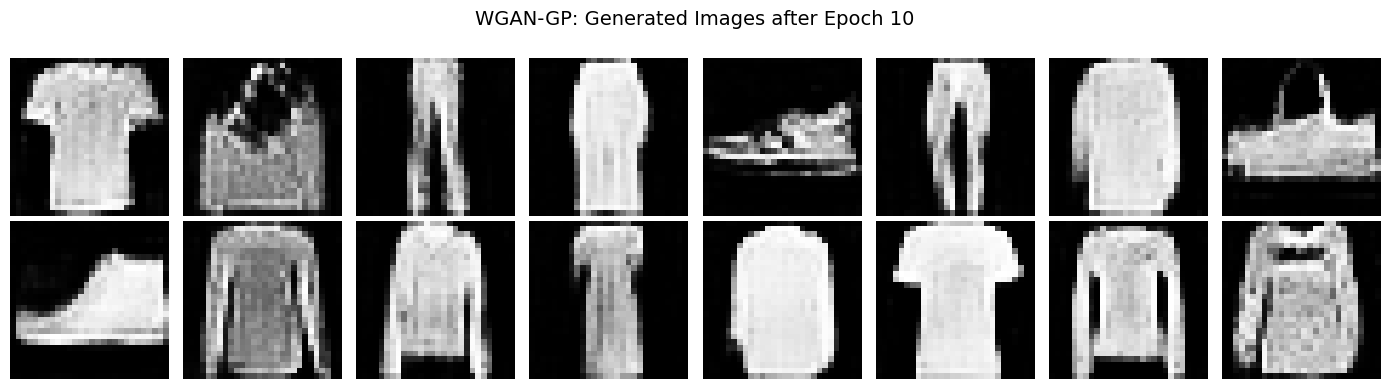

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 72s 39ms/step - d_loss: -5.0856 - g_loss: -12.7052


In [ ]:
# Instantiate the optimizer for both networks
generator_optimizer = keras.optimizers.Adam(learning_rate=learning_rate, beta_1=beta_1, beta_2=beta_2)
discriminator_optimizer = keras.optimizers.Adam(learning_rate=learning_rate, beta_1=beta_1, beta_2=beta_2)

# Define the loss functions for the discriminator,
# which should be (fake_loss - real_loss).
# We will add the gradient penalty later to this loss function.
def discriminator_loss(real_img, fake_img):
    real_loss = tf.reduce_mean(real_img)
    fake_loss = tf.reduce_mean(fake_img)
    return fake_loss - real_loss

# Define the loss functions for the generator.
def generator_loss(fake_img):
    return -tf.reduce_mean(fake_img)

# Get the wgan model
wgan = WGAN(
    discriminator=d_model,
    generator=g_model,
    latent_dim=noise_dim,
    discriminator_extra_steps=discriminator_extra_steps,
)

# Compile the wgan model
wgan.compile(
    d_optimizer=discriminator_optimizer,
    g_optimizer=generator_optimizer,
    g_loss_fn=generator_loss,
    d_loss_fn=discriminator_loss,
)

# Start training
wgan_history = wgan.fit(wgan_train_ds, epochs=num_epochs, callbacks=[GANMonitor()])

## DDPM

### Gaussian diffusion utilities

In [9]:

class GaussianDiffusion:
    """Gaussian diffusion utility.

    Args:
        beta_start: Start value of the scheduled variance
        beta_end: End value of the scheduled variance
        timesteps: Number of time steps in the forward process
    """

    def __init__(
        self,
        beta_start=1e-4,
        beta_end=0.02,
        timesteps=1000,
        clip_min=-1.0,
        clip_max=1.0,
    ):
        self.beta_start = beta_start
        self.beta_end = beta_end
        self.timesteps = timesteps
        self.clip_min = clip_min
        self.clip_max = clip_max

        # Define the linear variance schedule
        self.betas = betas = np.linspace(
            beta_start,
            beta_end,
            timesteps,
            dtype=np.float64,  # Using float64 for better precision
        )
        self.num_timesteps = int(timesteps)

        alphas = 1.0 - betas
        alphas_cumprod = np.cumprod(alphas, axis=0)
        alphas_cumprod_prev = np.append(1.0, alphas_cumprod[:-1])

        self.betas = tf.constant(betas, dtype=tf.float32)
        self.alphas_cumprod = tf.constant(alphas_cumprod, dtype=tf.float32)
        self.alphas_cumprod_prev = tf.constant(alphas_cumprod_prev, dtype=tf.float32)

        # Calculations for diffusion q(x_t | x_{t-1}) and others
        self.sqrt_alphas_cumprod = tf.constant(
            np.sqrt(alphas_cumprod), dtype=tf.float32
        )

        self.sqrt_one_minus_alphas_cumprod = tf.constant(
            np.sqrt(1.0 - alphas_cumprod), dtype=tf.float32
        )

        self.log_one_minus_alphas_cumprod = tf.constant(
            np.log(1.0 - alphas_cumprod), dtype=tf.float32
        )

        self.sqrt_recip_alphas_cumprod = tf.constant(
            np.sqrt(1.0 / alphas_cumprod), dtype=tf.float32
        )
        self.sqrt_recipm1_alphas_cumprod = tf.constant(
            np.sqrt(1.0 / alphas_cumprod - 1), dtype=tf.float32
        )

        # Calculations for posterior q(x_{t-1} | x_t, x_0)
        posterior_variance = (
            betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)
        )
        self.posterior_variance = tf.constant(posterior_variance, dtype=tf.float32)

        # Log calculation clipped because the posterior variance is 0 at the beginning
        # of the diffusion chain
        self.posterior_log_variance_clipped = tf.constant(
            np.log(np.maximum(posterior_variance, 1e-20)), dtype=tf.float32
        )

        self.posterior_mean_coef1 = tf.constant(
            betas * np.sqrt(alphas_cumprod_prev) / (1.0 - alphas_cumprod),
            dtype=tf.float32,
        )

        self.posterior_mean_coef2 = tf.constant(
            (1.0 - alphas_cumprod_prev) * np.sqrt(alphas) / (1.0 - alphas_cumprod),
            dtype=tf.float32,
        )

    def _extract(self, a, t, x_shape):
        """Extract some coefficients at specified timesteps,
        then reshape to [batch_size, 1, 1, 1, 1, ...] for broadcasting purposes.

        Args:
            a: Tensor to extract from
            t: Timestep for which the coefficients are to be extracted
            x_shape: Shape of the current batched samples
        """
        batch_size = x_shape[0]
        out = tf.gather(a, t)
        return tf.reshape(out, [batch_size, 1, 1, 1])

    def q_mean_variance(self, x_start, t):
        """Extracts the mean, and the variance at current timestep.

        Args:
            x_start: Initial sample (before the first diffusion step)
            t: Current timestep
        """
        x_start_shape = tf.shape(x_start)
        mean = self._extract(self.sqrt_alphas_cumprod, t, x_start_shape) * x_start
        variance = self._extract(1.0 - self.alphas_cumprod, t, x_start_shape)
        log_variance = self._extract(
            self.log_one_minus_alphas_cumprod, t, x_start_shape
        )
        return mean, variance, log_variance

    def q_sample(self, x_start, t, noise):
        """Diffuse the data.

        Args:
            x_start: Initial sample (before the first diffusion step)
            t: Current timestep
            noise: Gaussian noise to be added at the current timestep
        Returns:
            Diffused samples at timestep `t`
        """
        x_start_shape = tf.shape(x_start)
        return (
            self._extract(self.sqrt_alphas_cumprod, t, tf.shape(x_start)) * x_start
            + self._extract(self.sqrt_one_minus_alphas_cumprod, t, x_start_shape)
            * noise
        )

    def predict_start_from_noise(self, x_t, t, noise):
        x_t_shape = tf.shape(x_t)
        return (
            self._extract(self.sqrt_recip_alphas_cumprod, t, x_t_shape) * x_t
            - self._extract(self.sqrt_recipm1_alphas_cumprod, t, x_t_shape) * noise
        )

    def q_posterior(self, x_start, x_t, t):
        """Compute the mean and variance of the diffusion
        posterior q(x_{t-1} | x_t, x_0).

        Args:
            x_start: Stating point(sample) for the posterior computation
            x_t: Sample at timestep `t`
            t: Current timestep
        Returns:
            Posterior mean and variance at current timestep
        """

        x_t_shape = tf.shape(x_t)
        posterior_mean = (
            self._extract(self.posterior_mean_coef1, t, x_t_shape) * x_start
            + self._extract(self.posterior_mean_coef2, t, x_t_shape) * x_t
        )
        posterior_variance = self._extract(self.posterior_variance, t, x_t_shape)
        posterior_log_variance_clipped = self._extract(
            self.posterior_log_variance_clipped, t, x_t_shape
        )
        return posterior_mean, posterior_variance, posterior_log_variance_clipped

    def p_mean_variance(self, pred_noise, x, t, clip_denoised=True):
        x_recon = self.predict_start_from_noise(x, t=t, noise=pred_noise)
        if clip_denoised:
            x_recon = tf.clip_by_value(x_recon, self.clip_min, self.clip_max)

        model_mean, posterior_variance, posterior_log_variance = self.q_posterior(
            x_start=x_recon, x_t=x, t=t
        )
        return model_mean, posterior_variance, posterior_log_variance

    def p_sample(self, pred_noise, x, t, clip_denoised=True):
        """Sample from the diffusion model.

        Args:
            pred_noise: Noise predicted by the diffusion model
            x: Samples at a given timestep for which the noise was predicted
            t: Current timestep
            clip_denoised (bool): Whether to clip the predicted noise
                within the specified range or not.
        """
        model_mean, _, model_log_variance = self.p_mean_variance(
            pred_noise, x=x, t=t, clip_denoised=clip_denoised
        )
        noise = tf.random.normal(shape=x.shape, dtype=x.dtype)
        # No noise when t == 0
        nonzero_mask = tf.reshape(
            1 - tf.cast(tf.equal(t, 0), tf.float32), [tf.shape(x)[0], 1, 1, 1]
        )
        return model_mean + nonzero_mask * tf.exp(0.5 * model_log_variance) * noise

### Network architecture

In [10]:

# Kernel initializer to use
def kernel_init(scale):
    scale = max(scale, 1e-10)
    return keras.initializers.VarianceScaling(
        scale, mode="fan_avg", distribution="uniform"
    )


class AttentionBlock(layers.Layer):
    """Applies self-attention.

    Args:
        units: Number of units in the dense layers
        groups: Number of groups to be used for GroupNormalization layer
    """

    def __init__(self, units, groups=8, **kwargs):
        self.units = units
        self.groups = groups
        super().__init__(**kwargs)

        self.norm = layers.GroupNormalization(groups=groups)
        self.query = layers.Dense(units, kernel_initializer=kernel_init(1.0))
        self.key = layers.Dense(units, kernel_initializer=kernel_init(1.0))
        self.value = layers.Dense(units, kernel_initializer=kernel_init(1.0))
        self.proj = layers.Dense(units, kernel_initializer=kernel_init(0.0))

    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        height = tf.shape(inputs)[1]
        width = tf.shape(inputs)[2]
        scale = tf.cast(self.units, tf.float32) ** (-0.5)

        inputs = self.norm(inputs)
        q = self.query(inputs)
        k = self.key(inputs)
        v = self.value(inputs)

        attn_score = tf.einsum("bhwc, bHWc->bhwHW", q, k) * scale
        attn_score = tf.reshape(attn_score, [batch_size, height, width, height * width])

        attn_score = tf.nn.softmax(attn_score, -1)
        attn_score = tf.reshape(attn_score, [batch_size, height, width, height, width])

        proj = tf.einsum("bhwHW,bHWc->bhwc", attn_score, v)
        proj = self.proj(proj)
        return inputs + proj


class TimeEmbedding(layers.Layer):
    def __init__(self, dim, **kwargs):
        super().__init__(**kwargs)
        self.dim = dim
        self.half_dim = dim // 2
        self.emb = math.log(10000) / (self.half_dim - 1)
        self.emb = tf.exp(tf.range(self.half_dim, dtype=tf.float32) * -self.emb)

    def call(self, inputs):
        inputs = tf.cast(inputs, dtype=tf.float32)
        emb = inputs[:, None] * self.emb[None, :]
        emb = tf.concat([tf.sin(emb), tf.cos(emb)], axis=-1)
        return emb


def ResidualBlock(width, groups=8, activation_fn=keras.activations.swish):
    def apply(inputs):
        x, t = inputs
        input_width = x.shape[3]

        if input_width == width:
            residual = x
        else:
            residual = layers.Conv2D(
                width, kernel_size=1, kernel_initializer=kernel_init(1.0)
            )(x)

        temb = activation_fn(t)
        temb = layers.Dense(width, kernel_initializer=kernel_init(1.0))(temb)[
            :, None, None, :
        ]

        x = layers.GroupNormalization(groups=groups)(x)
        x = activation_fn(x)
        x = layers.Conv2D(
            width, kernel_size=3, padding="same", kernel_initializer=kernel_init(1.0)
        )(x)

        x = layers.Add()([x, temb])
        x = layers.GroupNormalization(groups=groups)(x)
        x = activation_fn(x)

        x = layers.Conv2D(
            width, kernel_size=3, padding="same", kernel_initializer=kernel_init(0.0)
        )(x)
        x = layers.Add()([x, residual])
        return x

    return apply


def DownSample(width):
    def apply(x):
        x = layers.Conv2D(
            width,
            kernel_size=3,
            strides=2,
            padding="same",
            kernel_initializer=kernel_init(1.0),
        )(x)
        return x

    return apply


def UpSample(width, interpolation="nearest"):
    def apply(x):
        x = layers.UpSampling2D(size=2, interpolation=interpolation)(x)
        x = layers.Conv2D(
            width, kernel_size=3, padding="same", kernel_initializer=kernel_init(1.0)
        )(x)
        return x

    return apply


def TimeMLP(units, activation_fn=keras.activations.swish):
    def apply(inputs):
        temb = layers.Dense(
            units, activation=activation_fn, kernel_initializer=kernel_init(1.0)
        )(inputs)
        temb = layers.Dense(units, kernel_initializer=kernel_init(1.0))(temb)
        return temb

    return apply


def build_model(
    img_size,
    img_channels,
    widths,
    has_attention,
    num_res_blocks=2,
    norm_groups=8,
    interpolation="nearest",
    activation_fn=keras.activations.swish,
):
    image_input = layers.Input(
        shape=(img_size, img_size, img_channels), name="image_input"
    )
    time_input = keras.Input(shape=(), dtype=tf.int64, name="time_input")

    x = layers.Conv2D(
        first_conv_channels,
        kernel_size=(3, 3),
        padding="same",
        kernel_initializer=kernel_init(1.0),
    )(image_input)

    temb = TimeEmbedding(dim=first_conv_channels * 4)(time_input)
    temb = TimeMLP(units=first_conv_channels * 4, activation_fn=activation_fn)(temb)

    skips = [x]

    # DownBlock
    for i in range(len(widths)):
        for _ in range(num_res_blocks):
            x = ResidualBlock(
                widths[i], groups=norm_groups, activation_fn=activation_fn
            )([x, temb])
            if has_attention[i]:
                x = AttentionBlock(widths[i], groups=norm_groups)(x)
            skips.append(x)

        if widths[i] != widths[-1]:
            x = DownSample(widths[i])(x)
            skips.append(x)

    # MiddleBlock
    x = ResidualBlock(widths[-1], groups=norm_groups, activation_fn=activation_fn)(
        [x, temb]
    )
    x = AttentionBlock(widths[-1], groups=norm_groups)(x)
    x = ResidualBlock(widths[-1], groups=norm_groups, activation_fn=activation_fn)(
        [x, temb]
    )

    # UpBlock
    for i in reversed(range(len(widths))):
        for _ in range(num_res_blocks + 1):
            x = layers.Concatenate(axis=-1)([x, skips.pop()])
            x = ResidualBlock(
                widths[i], groups=norm_groups, activation_fn=activation_fn
            )([x, temb])
            if has_attention[i]:
                x = AttentionBlock(widths[i], groups=norm_groups)(x)

        if i != 0:
            x = UpSample(widths[i], interpolation=interpolation)(x)

    # End block
    x = layers.GroupNormalization(groups=norm_groups)(x)
    x = activation_fn(x)
    x = layers.Conv2D(img_channels, (3, 3), padding="same", kernel_initializer=kernel_init(0.0))(x)
    return keras.Model([image_input, time_input], x, name="unet")

### Training

Epoch 1/10


I0000 00:00:1775088260.674381 2232787 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_12385023__.759


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - loss: 0.1066

I0000 00:00:1775088550.046550 2232787 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_12397717__.135


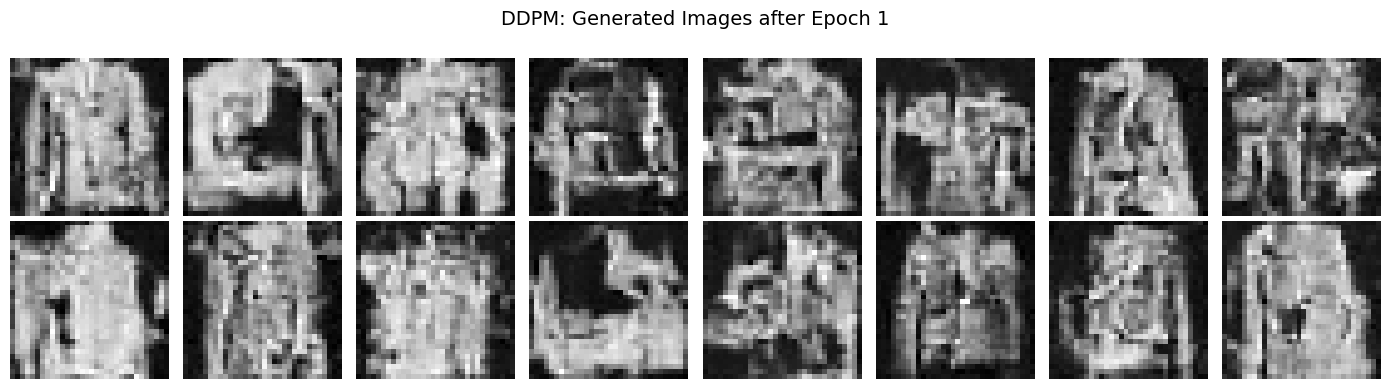

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 400s 182ms/step - loss: 0.0502
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - loss: 0.0304

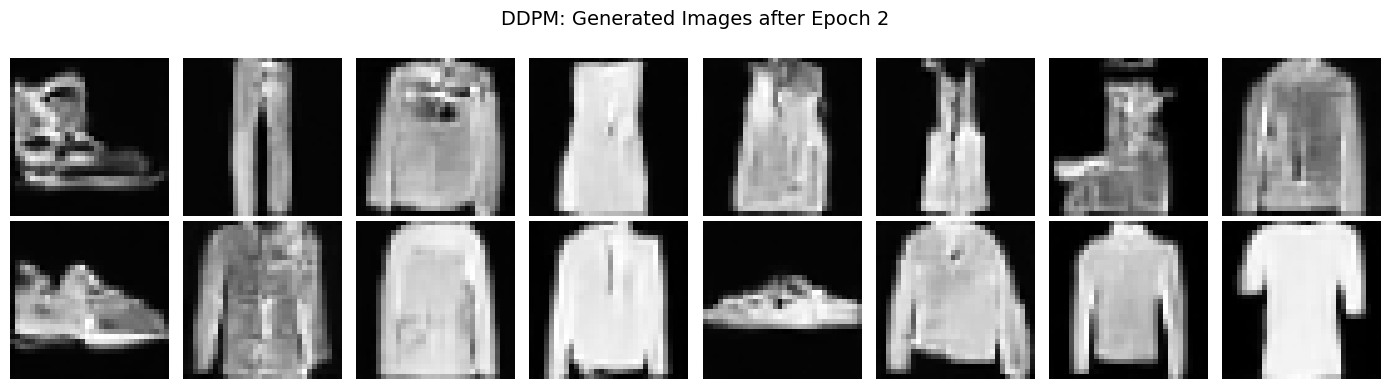

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 332s 177ms/step - loss: 0.0300
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - loss: 0.0283

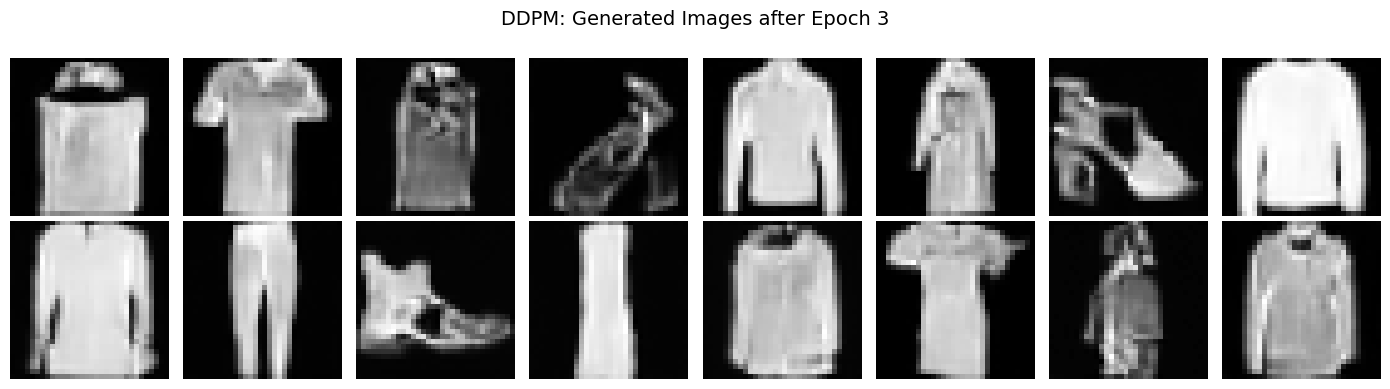

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 309s 165ms/step - loss: 0.0278
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - loss: 0.0277

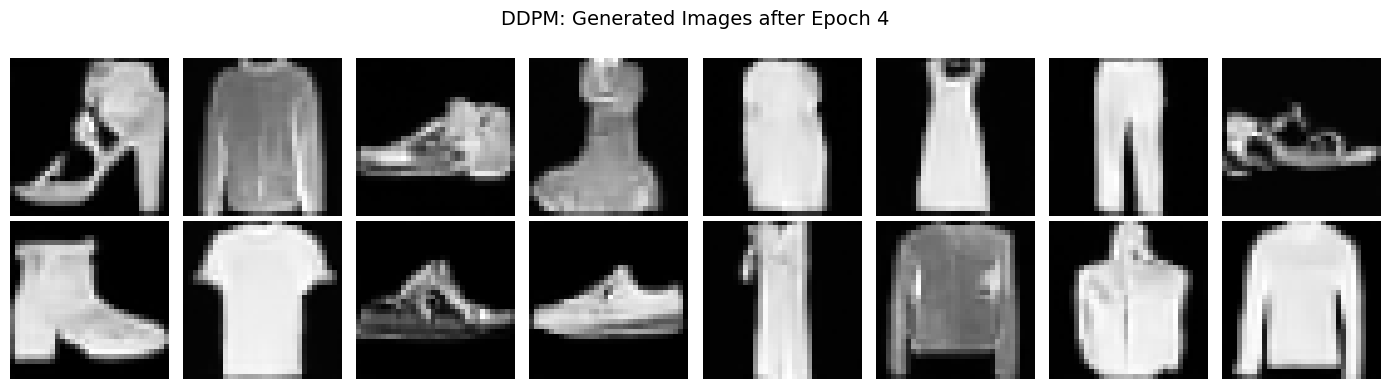

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 327s 174ms/step - loss: 0.0274
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - loss: 0.0263

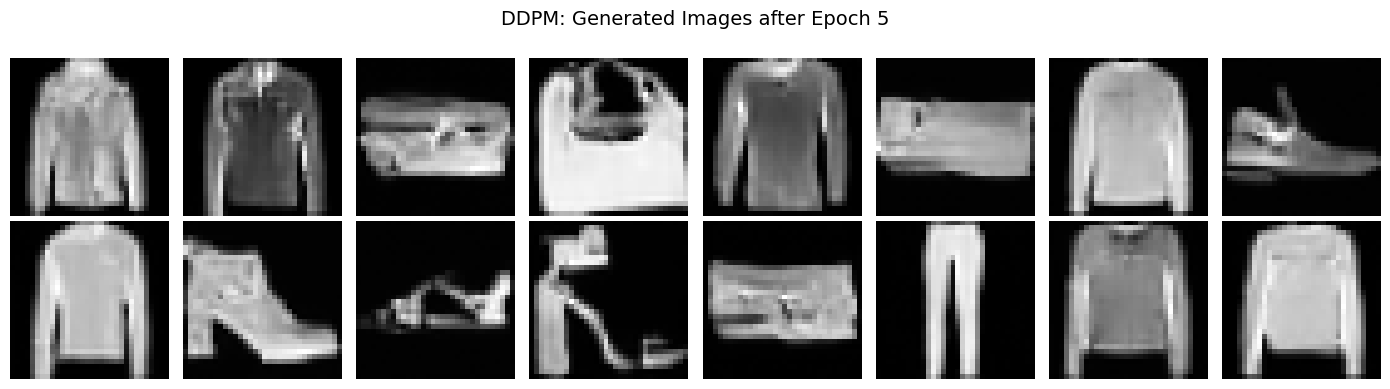

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 337s 180ms/step - loss: 0.0260
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - loss: 0.0258

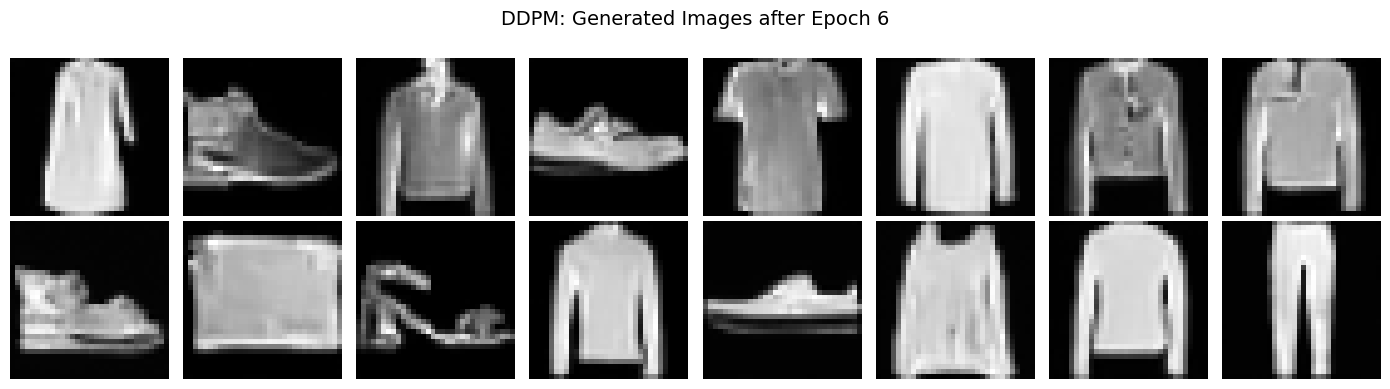

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 340s 181ms/step - loss: 0.0259
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - loss: 0.0253

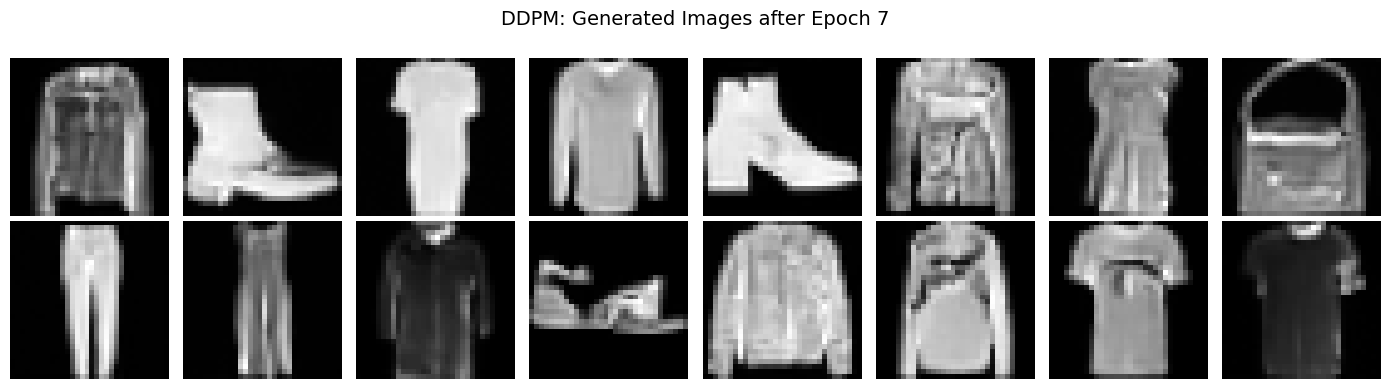

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 337s 180ms/step - loss: 0.0253
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - loss: 0.0249

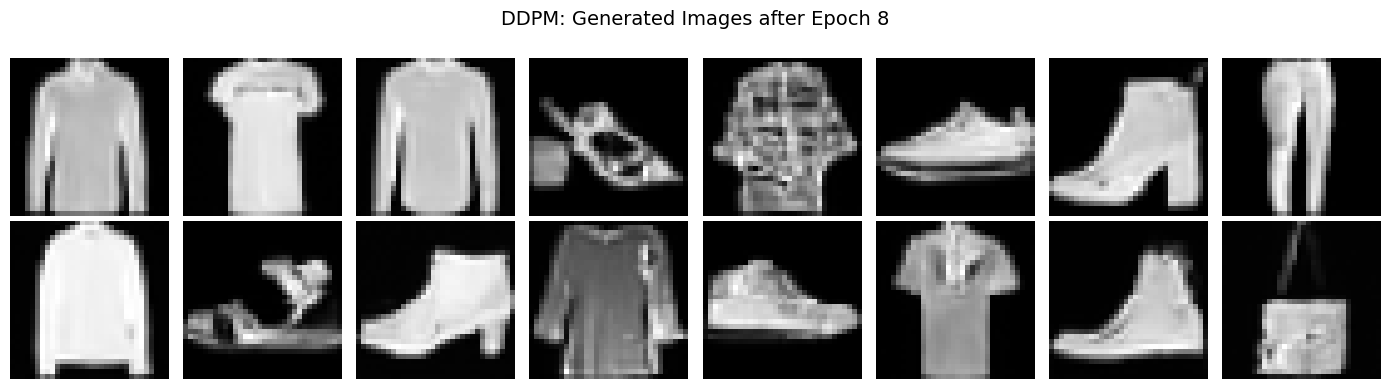

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 339s 181ms/step - loss: 0.0251
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - loss: 0.0251

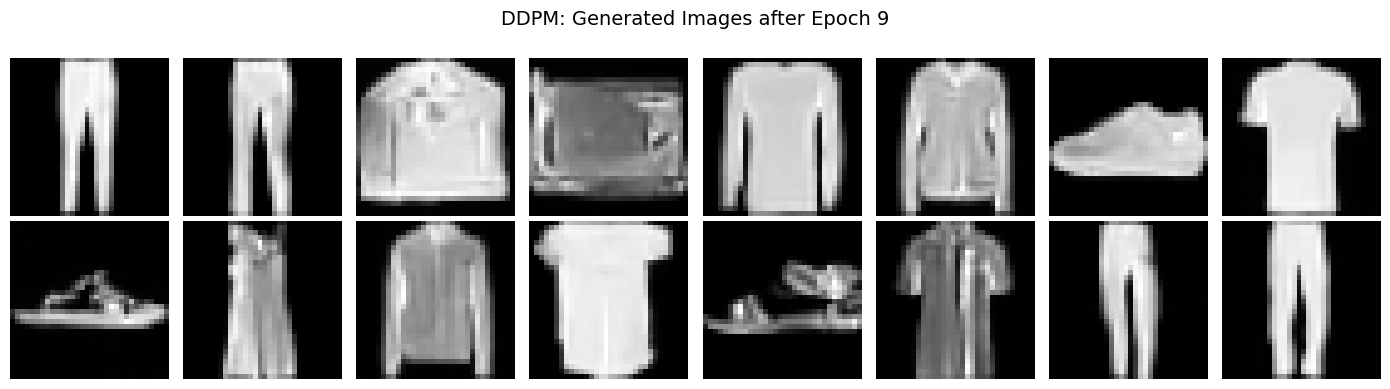

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 336s 179ms/step - loss: 0.0250
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - loss: 0.0251

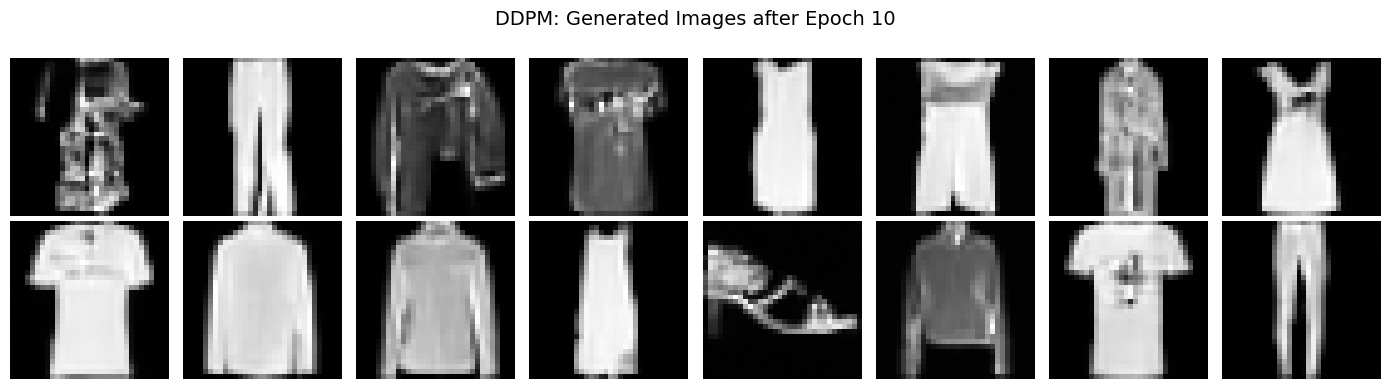

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 342s 183ms/step - loss: 0.0248


In [17]:

class DiffusionModel(keras.Model):
    def __init__(self, network, ema_network, timesteps, gdf_util, ema=0.999):
        super().__init__()
        self.network = network
        self.ema_network = ema_network
        self.timesteps = timesteps
        self.gdf_util = gdf_util
        self.ema = ema
        self.loss_tracker = keras.metrics.Mean(name="loss")
    
    @property
    def metrics(self):
        return [self.loss_tracker]

    def train_step(self, images):
        # 1. Get the batch size
        batch_size = tf.shape(images)[0]

        # 2. Sample timesteps uniformly
        t = tf.random.uniform(
            minval=0, maxval=self.timesteps, shape=(batch_size,), dtype=tf.int64
        )

        with tf.GradientTape() as tape:
            # 3. Sample random noise to be added to the images in the batch
            noise = tf.random.normal(shape=tf.shape(images), dtype=images.dtype)

            # 4. Diffuse the images with noise
            images_t = self.gdf_util.q_sample(images, t, noise)

            # 5. Pass the diffused images and time steps to the network
            pred_noise = self.network([images_t, t], training=True)

            # 6. Calculate the loss
            loss = self.loss(noise, pred_noise)

        # 7. Get the gradients
        gradients = tape.gradient(loss, self.network.trainable_weights)

        # 8. Update the weights of the network
        self.optimizer.apply_gradients(zip(gradients, self.network.trainable_weights))

        # 9. Updates the weight values for the network with EMA weights
        for weight, ema_weight in zip(self.network.weights, self.ema_network.weights):
            ema_weight.assign(self.ema * ema_weight + (1 - self.ema) * weight)

        # 10. Update and return loss values
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    def generate_images(self, num_images=16):
        # 1. Randomly sample noise (starting point for reverse process)
        samples = tf.random.normal(
            shape=(num_images, img_size, img_size, img_channels), dtype=tf.float32
        )
        # 2. Sample from the model iteratively
        for t in reversed(range(0, self.timesteps)):
            tt = tf.cast(tf.fill(num_images, t), dtype=tf.int64)
            pred_noise = self.ema_network.predict(
                [samples, tt], verbose=0, batch_size=num_images
            )
            samples = self.gdf_util.p_sample(
                pred_noise, samples, tt, clip_denoised=True
            )
        # 3. Return generated samples
        return samples

    def plot_images(
        self, epoch=None, logs=None, num_rows=2, num_cols=8, figsize=(14, 4), samples_dir=samples_dir
    ):
        """Utility to plot images using the diffusion model during training."""
        save_dir = samples_dir
        os.makedirs(save_dir, exist_ok=True)

        generated_samples = self.generate_images(num_images=num_rows * num_cols)
        generated_samples = (
            tf.clip_by_value(generated_samples * 127.5 + 127.5, 0.0, 255.0)
            .numpy()
            .astype(np.uint8)
        )

        fig, ax = plt.subplots(num_rows, num_cols, figsize=figsize)
        for i, image in enumerate(generated_samples):
            if img_channels == 1:
                image = image.squeeze(-1)
            ax[i // num_cols, i % num_cols].imshow(image, cmap="gray" if img_channels == 1 else None)
            ax[i // num_cols, i % num_cols].axis("off")

        display_epoch = (epoch + 1) if epoch is not None else "N/A"
        fig.suptitle(f"DDPM: Generated Images after Epoch {display_epoch}", fontsize=14)
        plt.tight_layout()
        fig.savefig(os.path.join(save_dir, f"ddpm_epoch_{display_epoch:03d}.png"), dpi=150, bbox_inches="tight")
        plt.show()


# Build the unet model
network = build_model(
    img_size=img_size,
    img_channels=img_channels,
    widths=widths,
    has_attention=has_attention,
    num_res_blocks=num_res_blocks,
    norm_groups=norm_groups,
    activation_fn=keras.activations.swish,
)
ema_network = build_model(
    img_size=img_size,
    img_channels=img_channels,
    widths=widths,
    has_attention=has_attention,
    num_res_blocks=num_res_blocks,
    norm_groups=norm_groups,
    activation_fn=keras.activations.swish,
)
ema_network.set_weights(network.get_weights())  # Initially the weights are the same

# Get an instance of the Gaussian Diffusion utilities
gdf_util = GaussianDiffusion(timesteps=total_timesteps)

# Get the model
model = DiffusionModel(
    network=network,
    ema_network=ema_network,
    gdf_util=gdf_util,
    timesteps=total_timesteps,
)

# Compile the model
model.compile(
    loss=keras.losses.MeanSquaredError(),
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate, beta_1=beta_1, beta_2=beta_2),
)

# Train the model
ddpm_history = model.fit(
    train_ds,
    epochs=num_epochs,
    batch_size=batch_size,
    callbacks=[keras.callbacks.LambdaCallback(on_epoch_end=model.plot_images)],
)

# Evaluation

## Quantitative Evaluation: Inception Score (IS) & FID

In [15]:
# Load InceptionV3 models
inception_fid = InceptionV3(include_top=False, pooling="avg", input_shape=(299, 299, 3), weights="imagenet")
inception_is = InceptionV3(include_top=True, input_shape=(299, 299, 3), weights="imagenet")

# Utility functions for preprocessing and metric calculations
def preprocess_for_inception(images):
    """Prepare images for InceptionV3: resize to 299x299, convert grayscale to RGB, scale to [-1, 1]."""
    # Ensure float32 and pixel range [0, 255]
    images = tf.cast(images, tf.float32)
    if tf.reduce_max(images) <= 1.0:
        images = images * 255.0

    # Grayscale -> RGB by repeating channels
    if images.shape[-1] == 1:
        images = tf.repeat(images, 3, axis=-1)

    # Resize to 299x299
    images = tf.image.resize(images, (299, 299), method="bicubic", antialias=True)

    # Apply InceptionV3 preprocessing (scales to [-1, 1])
    images = preprocess_input(images)
    return images

def get_inception_features(images, batch_size=32):
    """Extract 2048-d feature vectors from InceptionV3 for FID."""
    images = preprocess_for_inception(images)
    features = inception_fid.predict(images, batch_size=batch_size, verbose=0)
    return features

def get_inception_predictions(images, batch_size=32):
    """Get softmax predictions from InceptionV3 for IS."""
    images = preprocess_for_inception(images)
    preds = inception_is.predict(images, batch_size=batch_size, verbose=0)
    return preds

def calculate_inception_score(images, batch_size=32, splits=10):
    """Calculate Inception Score."""
    preds = get_inception_predictions(images, batch_size)
    scores = []
    n = len(preds)
    for i in range(splits):
        part = preds[i * (n // splits): (i + 1) * (n // splits)]
        p_y = np.mean(part, axis=0, keepdims=True)
        kl_div = part * (np.log(part + 1e-16) - np.log(p_y + 1e-16))
        kl_div = np.mean(np.sum(kl_div, axis=1))
        scores.append(np.exp(kl_div))
    return float(np.mean(scores)), float(np.std(scores))

def calculate_fid(real_images, generated_images, batch_size=32):
    """Calculate Frechet Inception Distance."""
    feat_real = get_inception_features(real_images, batch_size)
    feat_gen = get_inception_features(generated_images, batch_size)

    mu_real, sigma_real = np.mean(feat_real, axis=0), np.cov(feat_real, rowvar=False)
    mu_gen, sigma_gen = np.mean(feat_gen, axis=0), np.cov(feat_gen, rowvar=False)

    diff = mu_real - mu_gen
    covmean, _ = sqrtm(sigma_real @ sigma_gen, disp=False)

    # Numerical stability: remove imaginary components
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = diff @ diff + np.trace(sigma_real + sigma_gen - 2.0 * covmean)
    return float(fid)



# Generate samples from both models
num_eval_images = 1024
wgan_images = []
ddpm_images = []

for i in tqdm(range(0, num_eval_images, batch_size)):
    n = min(batch_size, num_eval_images - i)
    z = tf.random.normal(shape=(n, noise_dim))
    imgs = wgan.generator(z, training=False)
    imgs = (imgs * 127.5) + 127.5  # scale to [0, 255]
    wgan_images.append(imgs.numpy())
wgan_images = np.concatenate(wgan_images, axis=0)

ddpm_batch = 16  # smaller batch for DDPM since generation is slow
for i in tqdm(range(0, num_eval_images, ddpm_batch)):
    n = min(ddpm_batch, num_eval_images - i)
    imgs = model.generate_images(num_images=n)
    imgs = tf.clip_by_value(imgs * 127.5 + 127.5, 0.0, 255.0)
    ddpm_images.append(imgs.numpy())
ddpm_images = np.concatenate(ddpm_images, axis=0)

# Prepare real images for comparison (same number as generated)
real_images = train_images[:num_eval_images]
real_images = (real_images * 127.5) + 127.5  # scale back to [0, 255]

# Compute Metrics (IS and FID)
is_wgan_mean, is_wgan_std = calculate_inception_score(wgan_images)
is_ddpm_mean, is_ddpm_std = calculate_inception_score(ddpm_images)

fid_wgan = calculate_fid(real_images, wgan_images)
fid_ddpm = calculate_fid(real_images, ddpm_images)

# Print Results
print("\n" + "=" * 55)
print(f"{'Metric':<25} {'WGAN-GP':>12} {'DDPM':>12}")
print("=" * 55)
print(f"{'Inception Score (IS)':<25} {is_wgan_mean:>8.2f}±{is_wgan_std:<4.2f} {is_ddpm_mean:>7.2f}±{is_ddpm_std:<4.2f}")
print(f"{'FID (lower is better)':<25} {fid_wgan:>12.2f} {fid_ddpm:>12.2f}")
print("=" * 55)

100%|██████████| 64/64 [1:12:41<00:00, 68.15s/it]
W0000 00:00:1775088159.629502 2232402 cpu_allocator_impl.cc:82] Allocation of 1098559488 exceeds 10% of free system memory.
W0000 00:00:1775088160.959602 2232402 cpu_allocator_impl.cc:82] Allocation of 1098559488 exceeds 10% of free system memory.
W0000 00:00:1775088174.509470 2232786 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.22GiB (rounded to 2386063872)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
I0000 00:00:1775088174.509539 2232786 bfc_allocator.cc:1049] BFCAllocator dump for GPU_0_bfc
I0000 00:00:1775088174.509542 2232786 bfc_allocator.cc:1056] Bin (256): 	Total Chunks: 456, Chunks in use: 453. 114.0KiB allocated for chunks. 113.2KiB in use in bin. 66.6KiB client-requested in use in bin.
I0000 00:00:1775088174.509545


Metric                         WGAN-GP         DDPM
Inception Score (IS)          3.53±0.23    3.91±0.18
FID (lower is better)            61.07        36.11


## Qualitative Evaluation

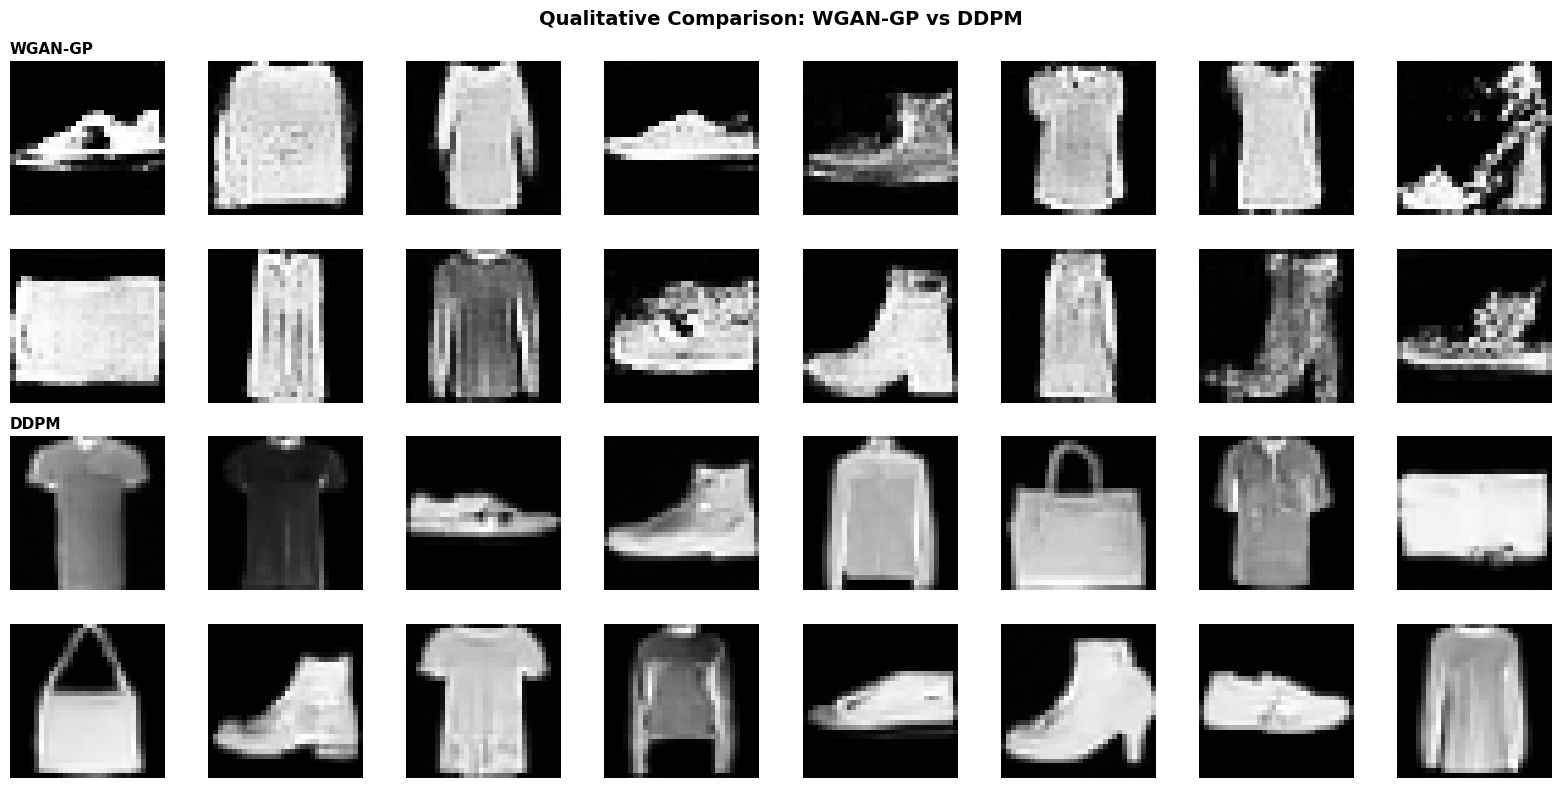


IS  — WGAN-GP: 3.53±0.23  |  DDPM: 3.91±0.18
FID — WGAN-GP: 61.07  |  DDPM: 36.11  (lower is better)


In [16]:
fig, axes = plt.subplots(4, 8, figsize=(16, 8))

# Top 2 rows: WGAN-GP
for i in range(16):
    img = wgan_images[i].squeeze(-1).clip(0, 255).astype(np.uint8)
    axes[i // 8, i % 8].imshow(img, cmap="gray")
    axes[i // 8, i % 8].axis("off")

# Bottom 2 rows: DDPM
for i in range(16):
    img = ddpm_images[i].squeeze(-1).clip(0, 255).astype(np.uint8)
    axes[2 + i // 8, i % 8].imshow(img, cmap="gray")
    axes[2 + i // 8, i % 8].axis("off")

# Row labels
axes[0, 0].set_title("WGAN-GP", fontsize=11, loc="left", fontweight="bold")
axes[2, 0].set_title("DDPM", fontsize=11, loc="left", fontweight="bold")

fig.suptitle("Qualitative Comparison: WGAN-GP vs DDPM", fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig("result/samples/qualitative_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Print summary again below the figure for easy reference
print(f"\nIS  — WGAN-GP: {is_wgan_mean:.2f}±{is_wgan_std:.2f}  |  DDPM: {is_ddpm_mean:.2f}±{is_ddpm_std:.2f}")
print(f"FID — WGAN-GP: {fid_wgan:.2f}  |  DDPM: {fid_ddpm:.2f}  (lower is better)")

# Training Dynamics Comparison

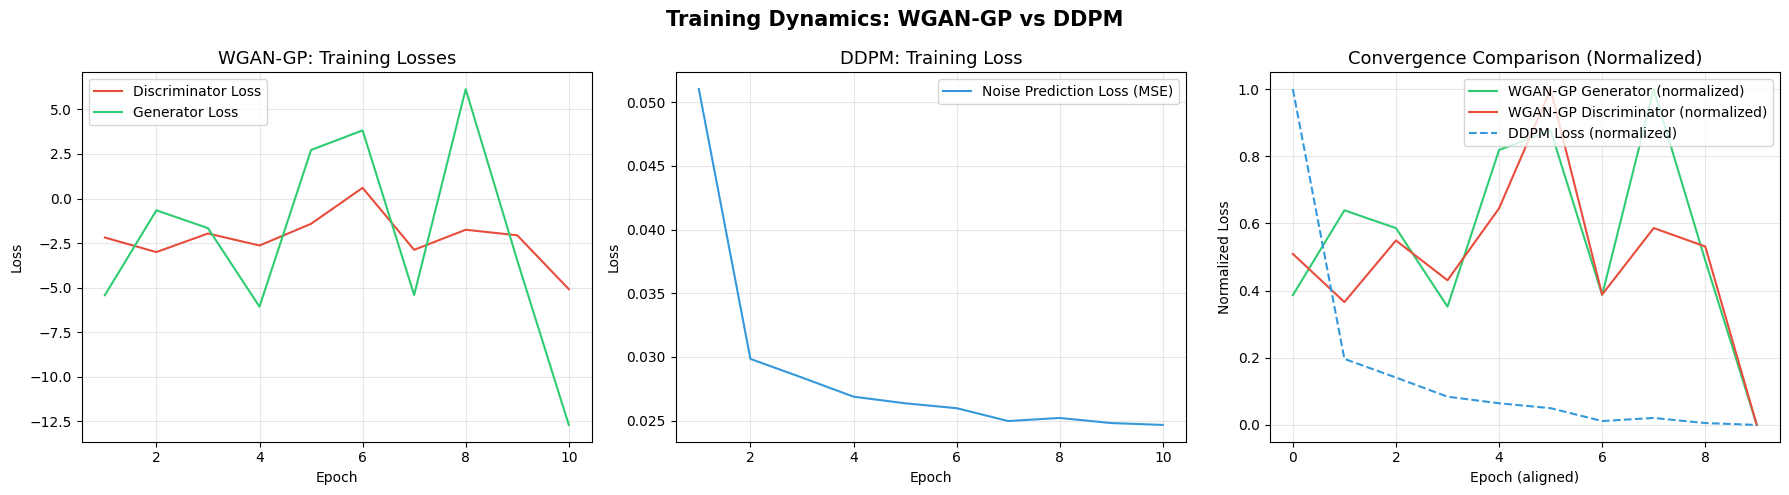


Key Observations:
  WGAN-GP — Final d_loss: -5.0856, g_loss: -12.7052
  DDPM    — Final loss:   0.0247
  WGAN-GP trained for 10 epochs
  DDPM    trained for 10 epochs


In [12]:
# Get epoch numbers for plotting
wgan_epochs = range(1, len(wgan_history.history["d_loss"]) + 1)
ddpm_epochs = range(1, len(ddpm_history.history["loss"]) + 1)

# Plot training losses and convergence comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(wgan_epochs, wgan_history.history["d_loss"], label="Discriminator Loss", color="#e74c3c")
axes[0].plot(wgan_epochs, wgan_history.history["g_loss"], label="Generator Loss", color="#2ecc71")
axes[0].set_title("WGAN-GP: Training Losses", fontsize=13)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(ddpm_epochs, ddpm_history.history["loss"], label="Noise Prediction Loss (MSE)", color="#3498db")
axes[1].set_title("DDPM: Training Loss", fontsize=13)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Normalize losses for convergence comparison
def normalize(vals):
    vals = np.array(vals, dtype=np.float32)
    return (vals - vals.min()) / (vals.max() - vals.min() + 1e-8)

axes[2].plot(normalize(wgan_history.history["g_loss"]), label="WGAN-GP Generator (normalized)", color="#2ecc71")
axes[2].plot(normalize(wgan_history.history["d_loss"]), label="WGAN-GP Discriminator (normalized)", color="#e74c3c")

ddpm_norm = normalize(ddpm_history.history["loss"])
ddpm_x = np.linspace(0, len(wgan_history.history["g_loss"]) - 1, len(ddpm_norm))
axes[2].plot(ddpm_x, ddpm_norm, label="DDPM Loss (normalized)", color="#3498db", linestyle="--")

# Align epochs for better comparison
axes[2].set_title("Convergence Comparison (Normalized)", fontsize=13)
axes[2].set_xlabel("Epoch (aligned)")
axes[2].set_ylabel("Normalized Loss")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

fig.suptitle("Training Dynamics: WGAN-GP vs DDPM", fontsize=15, fontweight="bold")
plt.tight_layout()
fig.savefig("result/samples/training_dynamics.png", dpi=150, bbox_inches="tight")
plt.show()

# Display key observations from the training dynamics and final metrics
print("\nKey Observations:")
print(f"  WGAN-GP — Final d_loss: {wgan_history.history['d_loss'][-1]:.4f}, g_loss: {wgan_history.history['g_loss'][-1]:.4f}")
print(f"  DDPM    — Final loss:   {ddpm_history.history['loss'][-1]:.4f}")
print(f"  WGAN-GP trained for {len(wgan_history.history['d_loss'])} epochs")
print(f"  DDPM    trained for {len(ddpm_history.history['loss'])} epochs")